# Early vs proficient sub-trial whisking correlations (LDA-free)

Does a mouse's **whisking timecourse along the trial** at the **first learning session** resemble
its timecourse when **proficient** — without reference to LDA1?

- **#2 Per-mouse stability:** correlate each mouse's early 40-bin whisking profile with its own
  proficient profile.
- **#3 Individuality:** is the **within-mouse** early-vs-proficient similarity higher than
  **between-mouse** (early mouse i vs proficient mouse j, i != j)? Permutation over mouse identity.
  This isolates the *individual* component from the shared average trial shape (both share the
  common epoch structure, so within>between is the real trait signal).

Proficient phase has **multiple sessions per mouse** -> profiles are **averaged per mouse** (one
proficient profile per mouse). Early phase has one session per mouse. Focus: whisk (state 1);
continuous variables can be added later via the `signal` hook.

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import pearsonr
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "segmentation", "1_camera_setup")))
from segmentation_functions import rescale_sequence

# --- paths --------------------------------------------
prefix = "/home/ines/repositories/" 
early_path = prefix + 'representation_learning_variability/paper-individuality/data/training/states_files/'
prof_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'
early_prefix = "4_states_file_"   # early files:      f"{early_prefix}{eid}_{mouse}"
prof_prefix  = "8_states_file_"                 # proficient files: f"{prof_prefix}{eid}_{mouse}"  (different prefix)

# --- signal: whisk on/off from identifiable_states -------------------------
whisk_digit_index = 1     # whisk = 2nd digit of identifiable_states "{paw}{whisk}{lick}[{wheel}]"
target_state      = 1     # 1 = whisking

# --- trial warping ---------------------------------------------------------
epochs        = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
target_length = 10
estimator     = "mode"    # discrete whisk state -> mode when compressing
# estimator     = "mean"    # discrete whisk state -> mode when compressing
L = len(epochs) * target_length
boundaries = [target_length * k for k in range(1, len(epochs))]
centers    = [target_length * k + target_length / 2 for k in range(len(epochs))]

In [2]:
def mouse_sessions(path, prefix):
    """{mouse: [eid, ...]} for files named f'{prefix}{eid}_{mouse}'."""
    out = {}
    for f in os.listdir(path):
        if f.startswith(prefix):
            rest = f[len(prefix):]          # "{eid}_{mouse}"
            eid, mouse = rest[:36], rest[37:]
            out.setdefault(mouse, []).append(eid)
    return out

early_ms = mouse_sessions(early_path, early_prefix)
prof_ms  = mouse_sessions(prof_path,  prof_prefix)
mice = sorted(set(early_ms) & set(prof_ms))
print(f"early: {len(early_ms)} mice | proficient: {len(prof_ms)} mice | common: {len(mice)} mice")
print("proficient sessions/mouse (sample):", {m: len(prof_ms[m]) for m in mice[:8]})

early: 38 mice | proficient: 102 mice | common: 38 mice
proficient sessions/mouse (sample): {'CSHL049': 4, 'CSHL052': 4, 'CSHL053': 4, 'CSHL058': 3, 'CSHL059': 5, 'CSH_ZAD_019': 4, 'CSH_ZAD_026': 6, 'CSH_ZAD_029': 4}


In [3]:
def signal(df):
    """Per-bin whisking indicator (0/1, NaN where undefined). Swap this for a continuous
    column (e.g. df['whisker_me']) later to run the same analysis on analog variables."""
    digit = pd.to_numeric(df["identifiable_states"].astype("string").str[whisk_digit_index],
                          errors="coerce")
    return np.where(digit.isna(), np.nan, (digit == target_state).astype(float))


def session_profile(path, prefix, eid, mouse):
    """40-bin profile for one session: per-trial warp (mode) within each phase, averaged
    across trials, epochs concatenated in order."""
    df = pd.read_parquet(os.path.join(path, f"{prefix}{eid}_{mouse}")).copy()
    df["_s"] = signal(df)
    # df["_s"] = np.abs(df['avg_wheel_vel'])
    df = df.dropna(subset=["broader_label", "_s", "trial_id"])
    prof = []
    for ph in epochs:
        d = df[df["broader_label"] == ph]
        if len(d) == 0:
            prof.append(np.full(target_length, np.nan)); continue
        seqs = (d.groupby("trial_id")["_s"].apply(list)
                  .map(lambda s: rescale_sequence(s, target_length, estimator)))
        M = np.vstack([np.asarray(x, dtype=float) for x in seqs])
        prof.append(np.nanmean(M, axis=0))
    return np.concatenate(prof)


# early = 1 session/mouse ; proficient = average across the mouse's sessions
E = np.full((len(mice), L), np.nan)
P = np.full((len(mice), L), np.nan)
for i, m in enumerate(mice):
    E[i] = session_profile(early_path, early_prefix, early_ms[m][0], m)
    P[i] = np.nanmean(np.vstack([session_profile(prof_path, prof_prefix, eid, m)
                                 for eid in prof_ms[m]]), axis=0)
print(f"profiles built: early {E.shape}, proficient {P.shape}")

profiles built: early (38, 40), proficient (38, 40)


## #2 Per-mouse stability (early vs proficient whisking profile)

per-mouse early-vs-proficient r: median=+0.696, mean=+0.657, n=38 mice


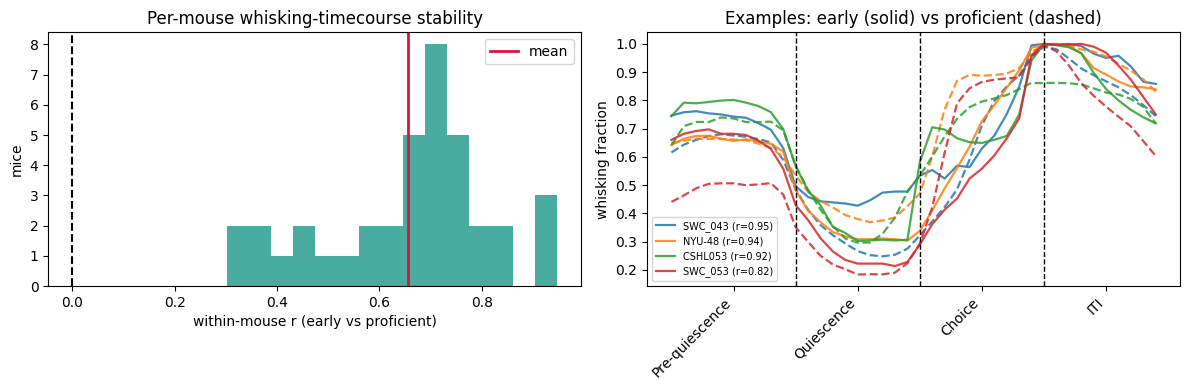

In [4]:
def prof_corr(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return pearsonr(a[m], b[m])[0] if m.sum() >= 3 else np.nan

within = np.array([prof_corr(E[i], P[i]) for i in range(len(mice))])
ok = np.isfinite(within)
print(f"per-mouse early-vs-proficient r: median={np.nanmedian(within):+.3f}, "
      f"mean={np.nanmean(within):+.3f}, n={ok.sum()} mice")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(within[ok], bins=15, color="#2a9d8f", alpha=.85)
axes[0].axvline(0, color="k", ls="--")
axes[0].axvline(np.nanmean(within), color="crimson", lw=2, label="mean")
axes[0].set_xlabel("within-mouse r (early vs proficient)"); axes[0].set_ylabel("mice")
axes[0].set_title("Per-mouse whisking-timecourse stability"); axes[0].legend()

ax = axes[1]
order = np.argsort(-np.nan_to_num(within, nan=-np.inf))    # most stable first
for i in order[:4]:
    line, = ax.plot(E[i], lw=1.6, alpha=.85, label=f"{mice[i]} (r={within[i]:.2f})")
    ax.plot(P[i], lw=1.6, ls="--", alpha=.85, color=line.get_color())
for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
ax.set_ylabel("whisking fraction")
ax.set_title("Examples: early (solid) vs proficient (dashed)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## #3 Individuality: within-mouse vs between-mouse (permutation)

within-mouse mean r = +0.657 | between-mouse mean r = +0.642
permutation p (within > random pairing) = 0.0086  (38 mice)


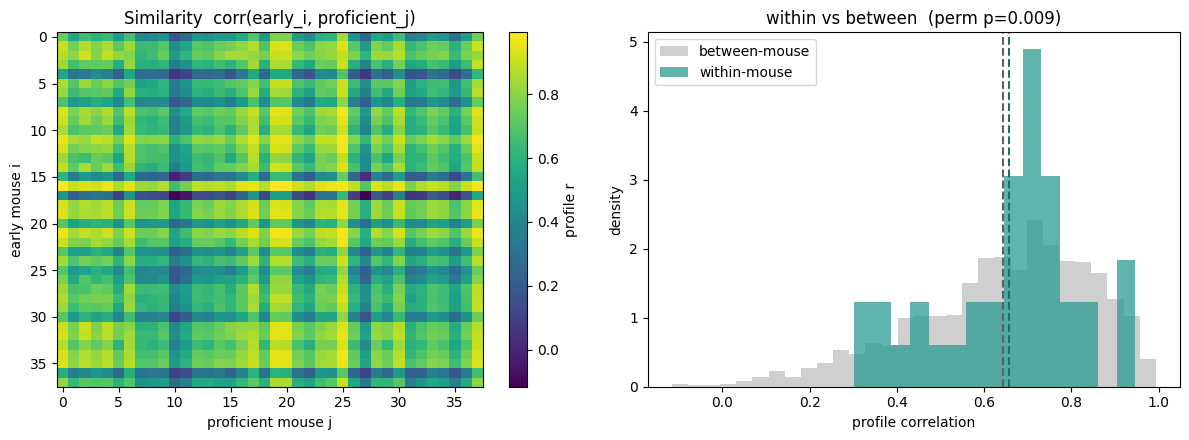

In [5]:
n = len(mice)
S = np.full((n, n), np.nan)                       # S[i,j] = corr(early_i, proficient_j)
for i in range(n):
    for j in range(n):
        S[i, j] = prof_corr(E[i], P[j])

diag = np.diag(S)                                 # matched (within-mouse) pairs
offdiag = S[~np.eye(n, dtype=bool)]               # mismatched (between-mouse) pairs
obs_within = np.nanmean(diag)

# permutation: shuffle proficient mouse identity, recompute mean matched-pair similarity
rng = np.random.default_rng(0); n_perm = 5000
null = np.empty(n_perm)
for k in range(n_perm):
    perm = rng.permutation(n)
    null[k] = np.nanmean([S[i, perm[i]] for i in range(n)])
p = (1 + np.sum(null >= obs_within)) / (n_perm + 1)

print(f"within-mouse mean r = {obs_within:+.3f} | between-mouse mean r = {np.nanmean(offdiag):+.3f}")
print(f"permutation p (within > random pairing) = {p:.4f}  ({n} mice)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im = axes[0].imshow(S, cmap="viridis", aspect="auto")
axes[0].set_xlabel("proficient mouse j"); axes[0].set_ylabel("early mouse i")
axes[0].set_title("Similarity  corr(early_i, proficient_j)")
plt.colorbar(im, ax=axes[0], label="profile r")

axes[1].hist(offdiag[np.isfinite(offdiag)], bins=30, density=True, alpha=.6,
             color="#b0b0b0", label="between-mouse")
axes[1].hist(diag[np.isfinite(diag)], bins=15, density=True, alpha=.75,
             color="#2a9d8f", label="within-mouse")
axes[1].axvline(np.nanmean(offdiag), color="#606060", ls="--")
axes[1].axvline(obs_within, color="#1d6f63", ls="--")
axes[1].set_xlabel("profile correlation"); axes[1].set_ylabel("density")
axes[1].set_title(f"within vs between  (perm p={p:.3f})"); axes[1].legend()
plt.tight_layout(); plt.show()

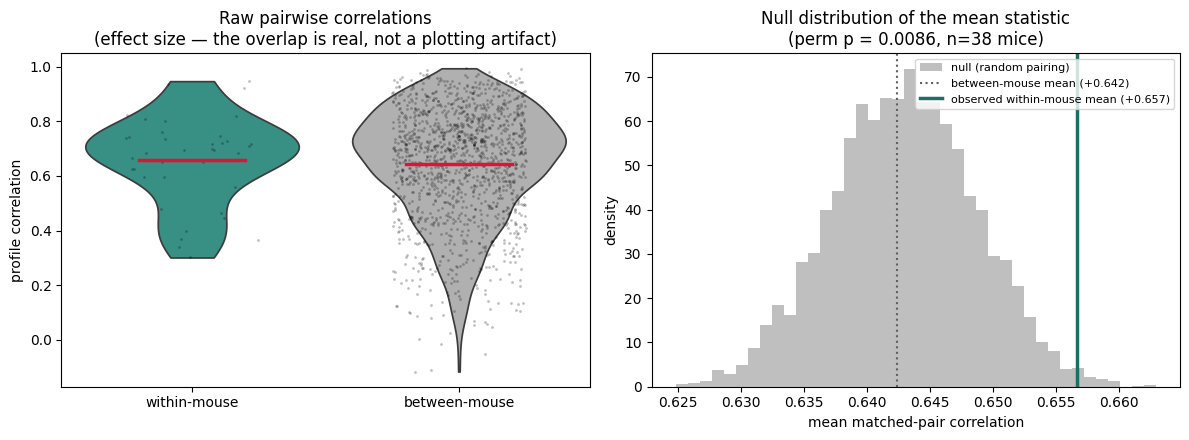

In [6]:
# ---- Panel A: raw pairwise correlations (effect size) — violin + individual points ----
df_pairs = pd.concat([
    pd.DataFrame({"pair": "within-mouse", "r": diag[np.isfinite(diag)]}),
    pd.DataFrame({"pair": "between-mouse", "r": offdiag[np.isfinite(offdiag)]}),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
sns.violinplot(data=df_pairs, x="pair", y="r", ax=ax, inner=None, cut=0,
                palette={"within-mouse": "#2a9d8f", "between-mouse": "#b0b0b0"})
sns.stripplot(data=df_pairs, x="pair", y="r", ax=ax, color="black", size=2, alpha=.25, jitter=.25)
for i, grp in enumerate(["within-mouse", "between-mouse"]):
    m = df_pairs.loc[df_pairs["pair"] == grp, "r"].mean()
    ax.plot([i - .2, i + .2], [m, m], color="crimson", lw=2.5, zorder=5)
ax.set_ylabel("profile correlation"); ax.set_xlabel("")
ax.set_title("Raw pairwise correlations\n(effect size — the overlap is real, not a plotting artifact)")

# ---- Panel B: permutation null of the MEAN statistic (significance) ----
ax = axes[1]
ax.hist(null, bins=40, color="#b0b0b0", alpha=.8, density=True, label="null (random pairing)")
ax.axvline(np.nanmean(offdiag), color="#606060", ls=":", lw=1.5,
           label=f"between-mouse mean ({np.nanmean(offdiag):+.3f})")
ax.axvline(obs_within, color="#1d6f63", lw=2.5,
           label=f"observed within-mouse mean ({obs_within:+.3f})")
ax.set_xlabel("mean matched-pair correlation"); ax.set_ylabel("density")
ax.set_title(f"Null distribution of the mean statistic\n(perm p = {p:.4f}, n={n} mice)")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## #4 Per-timepoint individuality: across-mouse correlation at each trial bin

#2/#3 correlate whole 40-bin profiles **within a mouse** (one number per mouse, or one number
overall) — any epoch-specific effect gets averaged away.

Here we flip which axis is correlated: for each of the 40 bins **separately**, take the
across-mice vector of early values and the across-mice vector of proficient values, and
correlate those. This gives a stability curve *over trial time* instead of one summary number,
so we can see *where* in the trial individual differences are preserved.

Caveat: if a mouse simply whisks more than others overall, that offset alone will inflate the
correlation at *every* bin uniformly, which would look like "individuality everywhere" but is
really just baseline-rate stability. So we compute it two ways:
- **raw** — baseline level + shape, both mixed in.
- **mean-centered** — each mouse's own across-bin mean subtracted first (separately for early
  and proficient), isolating stability of the *temporal shape* alone.

Significance is via permutation (shuffle which proficient mouse is paired with which early
mouse, as in #3) and FDR-corrected across the 40 bins.

raw per-bin r:      mean=+0.161, 0/40 bins FDR-sig
centered per-bin r: mean=+0.103, 0/40 bins FDR-sig


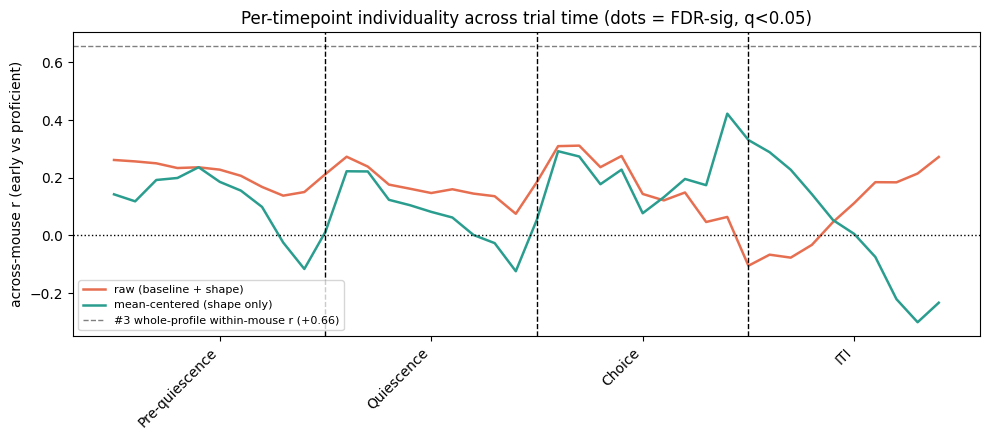

In [7]:
def bin_corr_curve(A, B):
    """Across-mice correlation at each of the L bins."""
    return np.array([prof_corr(A[:, t], B[:, t]) for t in range(A.shape[1])])

raw_curve = bin_corr_curve(E, P)

# mean-center each mouse's own profile (remove each mouse's overall level) to isolate
# shape-driven individuality from baseline-rate individuality
Ec = E - np.nanmean(E, axis=1, keepdims=True)
Pc = P - np.nanmean(P, axis=1, keepdims=True)
centered_curve = bin_corr_curve(Ec, Pc)

# permutation null: shuffle which proficient mouse is paired with which early mouse,
# recompute the per-bin across-mouse correlation under random pairing
rng = np.random.default_rng(0); n_perm = 2000
null_raw = np.empty((n_perm, L))
null_centered = np.empty((n_perm, L))
for k in range(n_perm):
    perm = rng.permutation(n)
    null_raw[k] = bin_corr_curve(E, P[perm])
    null_centered[k] = bin_corr_curve(Ec, Pc[perm])

p_raw = np.array([(1 + np.sum(null_raw[:, t] >= raw_curve[t])) / (n_perm + 1) for t in range(L)])
p_centered = np.array([(1 + np.sum(null_centered[:, t] >= centered_curve[t])) / (n_perm + 1) for t in range(L)])

def fdr_bh(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction; returns a boolean significance mask."""
    p = np.asarray(pvals); n = len(p)
    order = np.argsort(p); ranked = p[order]
    thresh = alpha * (np.arange(1, n + 1) / n)
    below = ranked <= thresh
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = ranked[np.max(np.where(below)[0])]
    return p <= cutoff

sig_raw = fdr_bh(p_raw)
sig_centered = fdr_bh(p_centered)

print(f"raw per-bin r:      mean={np.nanmean(raw_curve):+.3f}, {sig_raw.sum()}/{L} bins FDR-sig")
print(f"centered per-bin r: mean={np.nanmean(centered_curve):+.3f}, {sig_centered.sum()}/{L} bins FDR-sig")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(raw_curve, color="#e76f51", lw=1.8, label="raw (baseline + shape)")
ax.plot(centered_curve, color="#2a9d8f", lw=1.8, label="mean-centered (shape only)")
ax.scatter(np.where(sig_raw)[0], raw_curve[sig_raw], color="#e76f51", s=25, zorder=3)
ax.scatter(np.where(sig_centered)[0], centered_curve[sig_centered], color="#2a9d8f", s=25, zorder=3)
ax.axhline(0, color="k", ls=":", lw=1)
ax.axhline(obs_within, color="gray", ls="--", lw=1, label=f"#3 whole-profile within-mouse r ({obs_within:+.2f})")
for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
ax.set_ylabel("across-mouse r (early vs proficient)")
ax.set_title("Per-timepoint individuality across trial time (dots = FDR-sig, q<0.05)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## #5 Reference: proficient-only within-mouse reliability ceiling

#3's within-mouse mean (early vs proficient) mixes two things: genuine trait stability, and
whatever changes about the mouse's behavior *because of learning* between the early and
proficient stage. This section asks a narrower question, entirely **within the proficient
cohort** (no early-learning session involved): for a mouse with multiple proficient sessions,
hold out one session at random and correlate it against the mean of that mouse's *other*
proficient sessions. Same within-vs-between-mouse permutation test as #3.

This gives a same-stage reliability ceiling — how self-consistent a mouse is across sessions once
already proficient, absent any early-vs-late transition. Comparing it to #3's early-vs-proficient
value tells us how much of the early→proficient gap reflects real change vs. just ordinary
session-to-session noise. Mice with only one proficient session are excluded (no session to hold
out).

proficient-only reliability: 38 mice with >=2 sessions (excluded 0 with only 1)
proficient-only within-mouse mean r = +0.950 | between-mouse mean r = +0.873
permutation p = 0.0002  (38 mice)


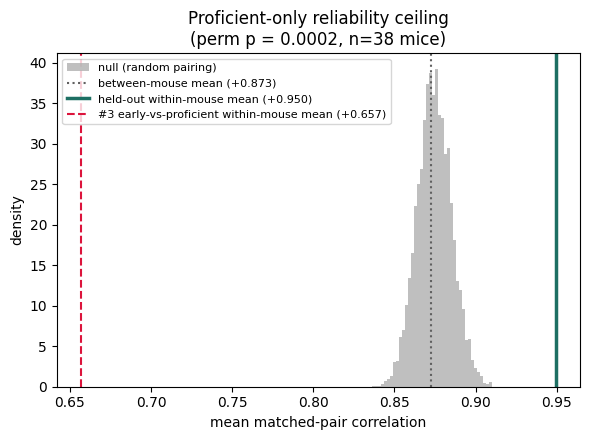

In [8]:
rng2 = np.random.default_rng(1)

# --- build per-session proficient profiles, hold one out per mouse (proficient cohort only) ---
mice2 = [m for m in mice if len(prof_ms[m]) >= 2]   # need >=2 sessions to hold one out
Q = np.full((len(mice2), L), np.nan)   # held-out session profile
R = np.full((len(mice2), L), np.nan)   # mean profile of the remaining proficient sessions

for i, m in enumerate(mice2):
    eids = prof_ms[m]
    held_out = rng2.choice(eids)
    rest = [e for e in eids if e != held_out]
    Q[i] = session_profile(prof_path, prof_prefix, held_out, m)
    R[i] = np.nanmean(np.vstack([session_profile(prof_path, prof_prefix, e, m) for e in rest]), axis=0)

print(f"proficient-only reliability: {len(mice2)} mice with >=2 sessions "
      f"(excluded {len(mice) - len(mice2)} with only 1)")

# --- within-mouse vs between-mouse, same permutation logic as #3 ---
n2 = len(mice2)
T = np.full((n2, n2), np.nan)   # T[i,j] = corr(Q_i held-out, R_j remaining-mean)
for i in range(n2):
    for j in range(n2):
        T[i, j] = prof_corr(Q[i], R[j])

diag2 = np.diag(T)
offdiag2 = T[~np.eye(n2, dtype=bool)]
obs_within2 = np.nanmean(diag2)

rng3 = np.random.default_rng(0); n_perm2 = 5000
null2 = np.empty(n_perm2)
for k in range(n_perm2):
    perm = rng3.permutation(n2)
    null2[k] = np.nanmean([T[i, perm[i]] for i in range(n2)])
p2 = (1 + np.sum(null2 >= obs_within2)) / (n_perm2 + 1)

print(f"proficient-only within-mouse mean r = {obs_within2:+.3f} | "
      f"between-mouse mean r = {np.nanmean(offdiag2):+.3f}")
print(f"permutation p = {p2:.4f}  ({n2} mice)")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(null2, bins=40, color="#b0b0b0", alpha=.8, density=True, label="null (random pairing)")
ax.axvline(np.nanmean(offdiag2), color="#606060", ls=":", lw=1.5,
           label=f"between-mouse mean ({np.nanmean(offdiag2):+.3f})")
ax.axvline(obs_within2, color="#1d6f63", lw=2.5,
           label=f"held-out within-mouse mean ({obs_within2:+.3f})")
ax.axvline(obs_within, color="crimson", ls="--", lw=1.5,
           label=f"#3 early-vs-proficient within-mouse mean ({obs_within:+.3f})")
ax.set_xlabel("mean matched-pair correlation"); ax.set_ylabel("density")
ax.set_title(f"Proficient-only reliability ceiling\n(perm p = {p2:.4f}, n={n2} mice)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

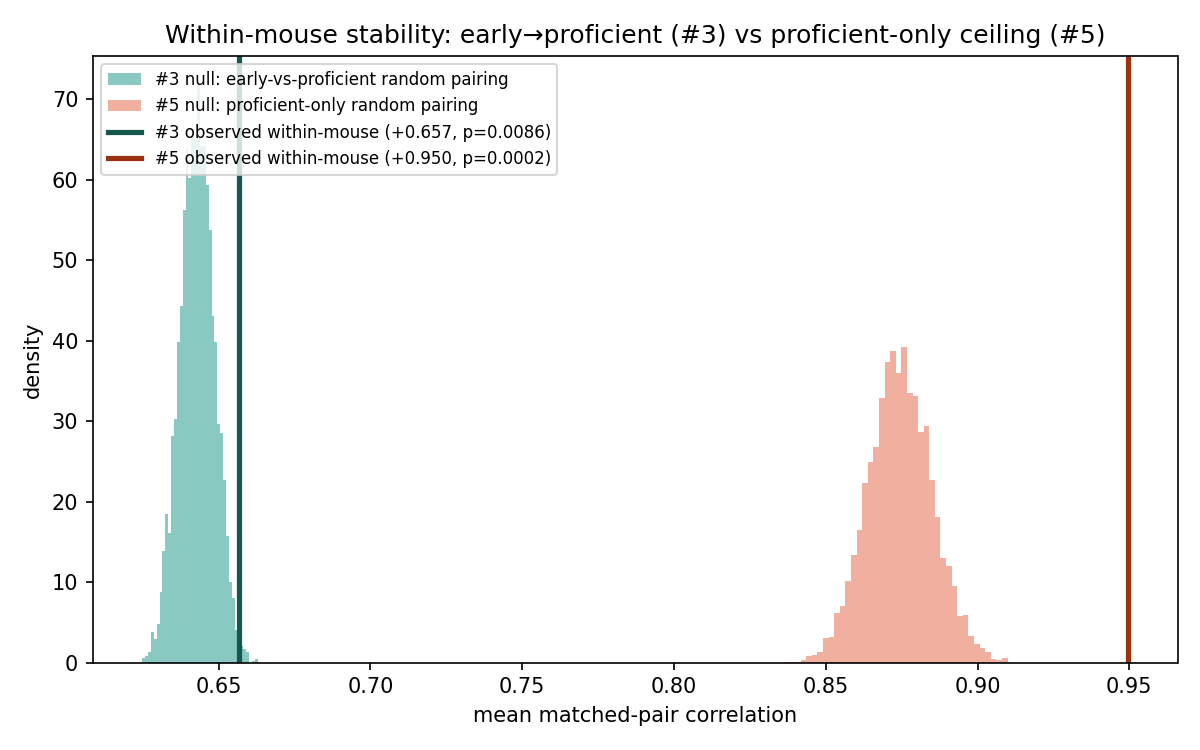

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(null, bins=40, density=True, alpha=.55, color="#2a9d8f",
        label="#3 null: early-vs-proficient random pairing")
ax.hist(null2, bins=40, density=True, alpha=.55, color="#e76f51",
        label="#5 null: proficient-only random pairing")
ax.axvline(obs_within, color="#16584f", lw=2.5,
           label=f"#3 observed within-mouse ({obs_within:+.3f}, p={p:.4f})")
ax.axvline(obs_within2, color="#9c3210", lw=2.5,
           label=f"#5 observed within-mouse ({obs_within2:+.3f}, p={p2:.4f})")
ax.set_xlabel("mean matched-pair correlation")
ax.set_ylabel("density")
ax.set_title("Within-mouse stability: early→proficient (#3) vs proficient-only ceiling (#5)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()